In [1]:
# %load_ext autoreload
# %autoreload 2

'''
Importing the modules
'''
import config_2Dcoupling_V3 as cfg              # config = physical & simulation parameters 
from solver_Hcurl_3D_V3 import *                # solver = FEM method + pmls
import diagnostic_post_process_V3 as my_pp      # post_process = plotting functions


In [2]:
solver = LHCouplingSolver_Hcurl3D(cfg.__dict__)
solver.build_physics_Stix_B_field(lambda x, z: my_pp.create_density_profile(x, z, solver))
mesh = solver.build_mesh_with_PMLs()
# print('num_vertices = ', mesh.nv)

GF_E_field, _ = solver.solve_helmholtz_Hcurl_3D_pml(mesh)

--- [Create_density_profile]: is_ngsolve = True ---
create_density_profile: prof_type = constant_density
type(ne) =  <class 'float'>
k0_vacuum = 77.546 m-1
Then Lz_exact = 0.200 m
n_perp_plus = 0.9347 ; n_perp_minus =  0.7710
n_perp_max = 0.9347 m-1


NameError: name 'k0_vaccum' is not defined


[SYSTEM] Dossier de sauvegarde créé : Simulation_Results/Run_20260429_140658
sim_target_folder:  /Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V3/Simulation_Results/Run_20260429_140658
Generating 2D wave E map...


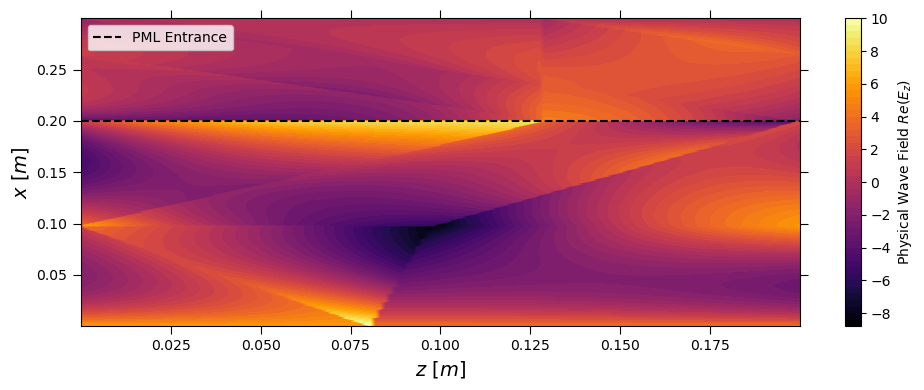

--- 2D map generation of (Ez) ---
Lz_plasma =  0.30000000000000004  m
len(x_vals) =  500 len(z_vals) =  500
len(X) =  500 len(Z) =  500
resolution_x =  500 resolution_z =  500


AttributeError: 'ngsolve.comp.ProxyFunction' object has no attribute 'components'

In [ ]:
# Post-treatment:

run_folder = my_pp.setup_output_directory("Simulation_Results")
sim_target_folder = '/Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V3/' + run_folder
print('sim_target_folder: ', sim_target_folder)

my_pp.plot_wave_3D(mesh, GF_E_field)


resolution_x, resolution_z = 500, 500
my_pp.Plot_E_field_2D_Map(solver, sim_target_folder, resolution_x, resolution_z, component ='Ez')

In [ ]:
# Pour faire des boucles sur les params de config_dict

cfg.DOMAIN['Lx_plasma'] = 30.
print(cfg.DOMAIN['Lx_plasma'] )

30.0
